In [6]:
from dotenv import load_dotenv
load_dotenv()


False

In [7]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages


llm = ChatOllama(model="phi3")

class State(TypedDict):
    messages: Annotated[list,add_messages]

    
def Chatbot(state: State)-> State:
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node",Chatbot)
builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()

message = {"role": "user", "content": "What is the capital of France?"}
response = graph.invoke({"messages": [message]})
response["messages"]

[HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='b30e0a9c-c3b4-46e3-be1e-25d9c36562cb'),
 AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={'model': 'phi3', 'created_at': '2026-03-09T18:38:46.95564Z', 'done': True, 'done_reason': 'stop', 'total_duration': 713634125, 'load_duration': 26752625, 'prompt_eval_count': 16, 'prompt_eval_duration': 398114291, 'eval_count': 8, 'eval_duration': 283693583, 'logprobs': None, 'model_name': 'phi3', 'model_provider': 'ollama'}, id='lc_run--019cd3e4-ffe0-7940-8ba6-14f2b8da433b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 8, 'total_tokens': 24})]

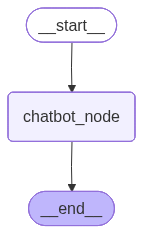

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
state = None
while True:
    user_input = input("You: ")
    if user_input.lower() in {"exit", "quit"}:
        break

    if state is None:
         state = {"messages": [{"role": "user", "content": user_input}]}
    else:         
        state["messages"].append({"role": "user", "content": user_input})
    
    state = graph.invoke(state)
    print("Chatbot:", state["messages"][-1].content)

KeyboardInterrupt: 